# Focused EDA — the personal-loan-only / credit-card-only target group

This notebook narrows the broad exploration in `analyze.ipynb` down to **one specific target group**:
customers who hold **exactly one product**, and that product is either a **personal loan** or a
**credit card** — the shallow, credit-led relationships the wider analysis surfaced as the natural
cross-sell target.

It reuses **EDA 1 and EDA 2 unchanged** (they establish that the market exists and give it a face), then
replaces the more general age, digital and location analyses with a tighter set aimed only at this
**811-customer** group:

- **EDA 3** — is the group genuinely younger-skewed?
- **EDA 4** — who are they and can the bank reach them digitally?
- **EDA 5** — which digital channel actually carries them, split by township status?
- **Extra** — income, credit and previous-closure profile, to scout for further opportunity.

Works **only** from the cleaned dataset `SBSA DS Case Study 2027 copy.csv`. No files are modified.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('SBSA DS Case Study 2027 copy.csv')

products = ['Current_Account', 'Savings_Account', 'Credit_Card', 'Personal_Loan', 'Home_Loan', 'Vehicle_Loan']
channels = ['Online_Banking', 'Mobile_App', 'USSD']

# one fixed colour per entity, reused consistently across every chart
BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE = '#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a', '#eb6834'
GRAY, INK, SOFT = '#898781', '#0b0b0b', '#52514e'
PRODUCT_COLORS = dict(zip(products, [BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE]))
CHANNEL_COLORS = dict(zip(channels, [BLUE, GREEN, MAGENTA]))

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.grid': True, 'grid.color': '#e1e0d9',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.axisbelow': True, 'font.size': 10,
})

def tidy(ax, pct=False):
    ax.grid(axis='x', visible=False)
    if pct:
        ax.set_ylim(0, 100)

print('Loaded cleaned dataset:', df.shape[0], 'customers,', df.shape[1], 'columns')

Loaded cleaned dataset: 9866 customers, 44 columns


**Setup.** Loads the cleaned data and fixes one colour per product and per channel, so the same thing
always looks the same across every chart in the notebook. Every percentage table printed alongside a chart
doubles as the exact numbers to quote in the presentation.

               Customers  Percentage
Products held                       
0                    576         5.8
1                   1870        19.0
2                   2816        28.5
3                   2535        25.7
4                   1531        15.5
5                    494         5.0
6                     44         0.4

Customers holding 0-2 products: 5262 (53.3% of the base)


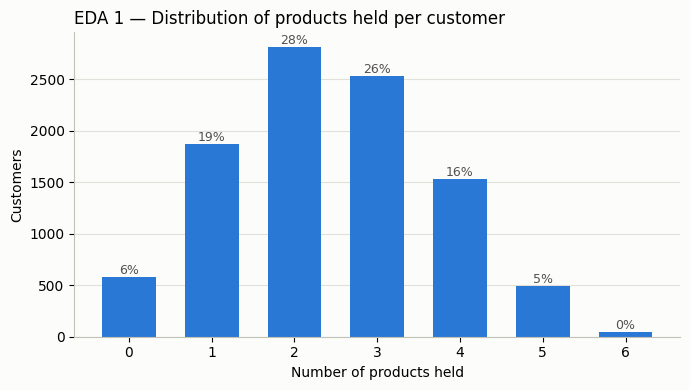

In [2]:
# ---- EDA 1: Distribution of number of products ----
counts = df['Num_Products'].value_counts().sort_index()
summary1 = pd.DataFrame({'Customers': counts,
                         'Percentage': (counts / len(df) * 100).round(1)})
summary1.index.name = 'Products held'
print(summary1)
low_share = (df['Num_Products'] <= 2).mean() * 100
print(f"\nCustomers holding 0-2 products: {(df['Num_Products'] <= 2).sum()} ({low_share:.1f}% of the base)")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(summary1.index.astype(str), summary1['Customers'], color=BLUE, width=0.65)
for bar, pct in zip(bars, summary1['Percentage']):
    ax.annotate(f'{pct:.0f}%', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9, color=SOFT)
ax.set_xlabel('Number of products held')
ax.set_ylabel('Customers')
ax.set_title('EDA 1 — Distribution of products held per customer', loc='left')
tidy(ax)
plt.tight_layout()
plt.show()

### EDA 1 — What this shows

Each bar is the number of customers holding that many of the bank's six products. The percentages on top
are the share of the whole (cleaned) customer base.

**The finding:** product holding is shallow. Over half the base — **53.3%** — holds **two products or
fewer**, including 19.0% with exactly one product and 5.8% with none at all. Only about 21% of customers
hold four or more.

**Why it matters:** a large low-product population is the precondition for a cross-selling /
personalization opportunity. If most customers already held 4–5 products there would be little room to
deepen relationships; instead, roughly every second customer has room to grow. The next EDAs zoom into who
these low-product customers are.

Single-product customers: 1870 (19.0% of the base)

                 Customers  % of single-product group  % of whole base
Only_Product                                                          
Personal_Loan          576                       30.8              5.8
Current_Account        511                       27.3              5.2
Savings_Account        347                       18.6              3.5
Credit_Card            235                       12.6              2.4
Vehicle_Loan           125                        6.7              1.3
Home_Loan               76                        4.1              0.8


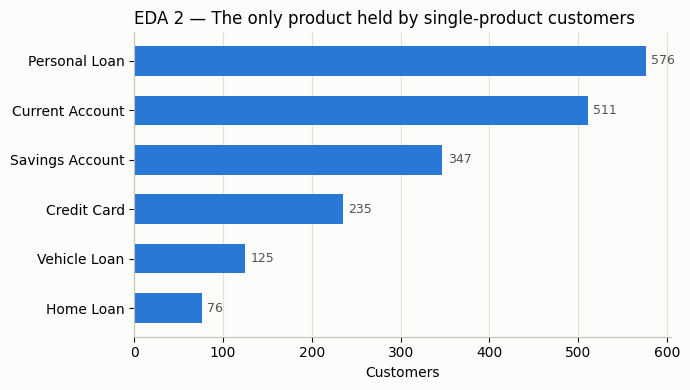

In [3]:
# ---- EDA 2: Products held by single-product customers ----
single = df[df['Num_Products'] == 1].copy()
single['Only_Product'] = single[products].idxmax(axis=1)

only_counts = single['Only_Product'].value_counts()
summary2 = pd.DataFrame({'Customers': only_counts,
                         '% of single-product group': (only_counts / len(single) * 100).round(1),
                         '% of whole base': (only_counts / len(df) * 100).round(1)})
print(f'Single-product customers: {len(single)} ({len(single) / len(df) * 100:.1f}% of the base)\n')
print(summary2)

fig, ax = plt.subplots(figsize=(7, 4))
labels = [p.replace('_', ' ') for p in only_counts.index]
bars = ax.barh(labels[::-1], only_counts.values[::-1], color=BLUE, height=0.6)
for bar in bars:
    ax.annotate(f'{int(bar.get_width())}', (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                ha='left', va='center', fontsize=9, color=SOFT,
                xytext=(4, 0), textcoords='offset points')
ax.set_xlabel('Customers')
ax.set_title('EDA 2 — The only product held by single-product customers', loc='left')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', color='#e1e0d9')
plt.tight_layout()
plt.show()

### EDA 2 — What this shows

Filtering to the 1,870 customers who hold **exactly one** product, this chart shows *which* product that
is.

**The finding:** the single biggest group is **personal-loan-only — 576 customers (30.8% of all
single-product customers, 5.8% of the entire base)**. It outranks current-account-only (511) and
savings-only (347); home-loan-only is the smallest (76).

**Why it matters:** a personal-loan-only customer is a striking relationship: the bank carries their credit
risk, yet holds none of their day-to-day banking — no transactional account, no savings. They borrow here
without holding any everyday banking relationship to match. That makes them the most natural cross-sell target in the base: the
relationship already exists, and the obvious next products (a transactional or savings account) are the
bank's cheapest to provide.

## Defining the target group

From here the notebook analyses **only** the single-product customers whose one product is a **personal
loan** or a **credit card** — the credit-led, shallow relationships. The comparison throughout is the
**full cleaned base of 9,866 customers**, so target percentages read against the whole book rather than a
residual group.

In [4]:
# ---- Target group: single-product customers whose only product is a Personal Loan or a Credit Card ----
target = single[single['Only_Product'].isin(['Personal_Loan', 'Credit_Card'])].copy()
target['Segment'] = np.where(target['Only_Product'] == 'Personal_Loan',
                             'Personal-loan-only', 'Credit-card-only')

# consistent age bands used throughout
band_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
band_bins = [17, 25, 35, 45, 55, 65, 200]
df['Age_Band'] = pd.cut(df['Age'], bins=band_bins, labels=band_labels)
target['Age_Band'] = pd.cut(target['Age'], bins=band_bins, labels=band_labels)

# flag every customer as target vs rest-of-base
df['Is_Target'] = df['CustomerID'].isin(target['CustomerID'])
rest = df[~df['Is_Target']]

n_pl = (target['Only_Product'] == 'Personal_Loan').sum()
n_cc = (target['Only_Product'] == 'Credit_Card').sum()
print(f'Target group: {len(target)} customers  '
      f'(personal-loan-only {n_pl}, credit-card-only {n_cc})')
print(f'Rest of base: {len(rest)} customers')

Target group: 811 customers  (personal-loan-only 576, credit-card-only 235)
Rest of base: 9055 customers


              Personal-loan-only  Credit-card-only  Combined target  \
Customers                  576.0             235.0            811.0   
Median age                  35.0              34.0             35.0   
% aged 18-35                51.4              54.0             52.2   

              Full base (9,866)  
Customers                9866.0  
Median age                 38.0  
% aged 18-35               42.0  

% of each age band that belongs to the target group:
       Band size  PL-only %  CC-only %  Target %
18-25       1612        9.9        4.5      14.3
26-35       2536        5.4        2.2       7.6
36-45       2892        4.3        2.3       6.6
46-55       1936        5.3        1.4       6.7
56-65        727        5.8        1.7       7.4
65+          163        6.7        1.8       8.6


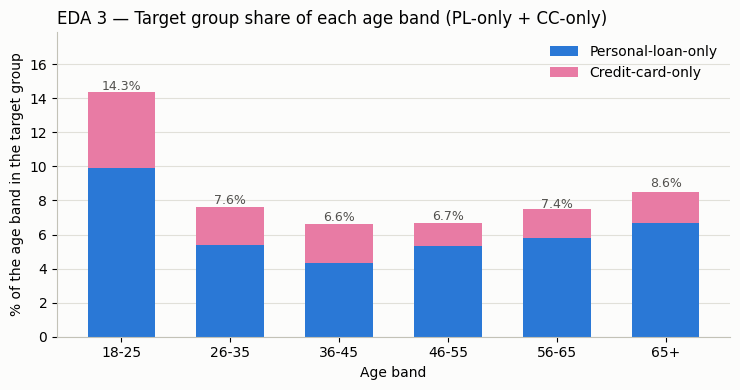

In [5]:
# ---- EDA 3: Age of the target group ----
def age_stats(g):
    return pd.Series({
        'Customers': len(g),
        'Median age': g['Age'].median(),
        '% aged 18-35': round((g['Age'] <= 35).mean() * 100, 1),
    })

summary3 = pd.DataFrame({
    'Personal-loan-only': age_stats(target[target['Only_Product'] == 'Personal_Loan']),
    'Credit-card-only': age_stats(target[target['Only_Product'] == 'Credit_Card']),
    'Combined target': age_stats(target),
    'Full base (9,866)': age_stats(df),
})
summary3.loc['Customers'] = summary3.loc['Customers'].astype(int)
print(summary3)

# share of EACH age band that falls into the target group, split PL-only vs CC-only
band_tab = pd.DataFrame(index=band_labels)
band_tab['Band size'] = df['Age_Band'].value_counts().reindex(band_labels)
band_tab['PL-only %'] = (target[target['Only_Product'] == 'Personal_Loan']['Age_Band']
                         .value_counts().reindex(band_labels).fillna(0) / band_tab['Band size'] * 100).round(1)
band_tab['CC-only %'] = (target[target['Only_Product'] == 'Credit_Card']['Age_Band']
                         .value_counts().reindex(band_labels).fillna(0) / band_tab['Band size'] * 100).round(1)
band_tab['Target %'] = (target['Age_Band'].value_counts().reindex(band_labels).fillna(0)
                        / band_tab['Band size'] * 100).round(1)
print('\n% of each age band that belongs to the target group:')
print(band_tab)

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(band_labels))
b1 = ax.bar(x, band_tab['PL-only %'], width=0.62, color=BLUE, label='Personal-loan-only')
b2 = ax.bar(x, band_tab['CC-only %'], width=0.62, bottom=band_tab['PL-only %'],
            color=MAGENTA, label='Credit-card-only')
for xi, tot in zip(x, band_tab['Target %']):
    ax.annotate(f'{tot:.1f}%', (xi, tot), ha='center', va='bottom', fontsize=9, color=SOFT)
ax.set_xticks(x)
ax.set_xticklabels(band_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('% of the age band in the target group')
ax.set_title('EDA 3 — Target group share of each age band (PL-only + CC-only)', loc='left')
ax.legend(frameon=False)
tidy(ax)
ax.set_ylim(0, max(band_tab['Target %']) * 1.25)
plt.tight_layout()
plt.show()

### EDA 3 — What this shows

Two simple views of the target group's age. The table compares median age and the share aged 18–35 across
the personal-loan-only, credit-card-only, combined-target groups and the **full cleaned base of 9,866
customers**. The bar chart flips the
question around: for **each age band**, what share of the customers in that band fall into the target group
— stacked into the personal-loan-only and credit-card-only parts (the labelled total is the whole
target share of the band).

**The finding:** the group is **younger-skewed, but not exclusively a youth group.**
- Median target age is **35**, and **52.2%** are aged 18–35, against **42.0%** of the full base (all 9,866
  customers).
- The skew is concentrated at the young end: **14.3% of all 18–25 customers are in the target group** —
  roughly double the ~7% share seen across most older bands. Within that, personal loans (9.9% of 18–25s)
  drive most of it, with credit cards adding 4.5%.
- But older bands are not empty — even 65+ sits near 8.6% — so this is a tilt, not a cliff.

**Why it matters:** it confirms the younger skew with evidence rather than assumption, which matters for how
the offer is framed and delivered. At the same time, because the group spans every age band, a campaign
built purely as a "youth" product would leave real volume on the table.

In [6]:
# ---- EDA 4: Target profile and location ----
n = len(target)
loc = target['Location_Type'].value_counts()

profile = {
    'Total target customers': f'{n}',
    '% of full base (9,866)': f"{n / len(df) * 100:.1f}%",
    '% of single-product customers': f"{n / len(single) * 100:.1f}%",
    'Personal-loan-only': f"{(target['Only_Product'] == 'Personal_Loan').sum()}",
    'Credit-card-only': f"{(target['Only_Product'] == 'Credit_Card').sum()}",
    'Median age': f"{target['Age'].median():.0f}",
    '% aged 18-35': f"{(target['Age'] <= 35).mean() * 100:.1f}%",
    'Township': f"{loc.get('Township', 0)} ({loc.get('Township', 0) / n * 100:.1f}%)",
    'Suburban': f"{loc.get('Suburban', 0)} ({loc.get('Suburban', 0) / n * 100:.1f}%)",
    'Urban': f"{loc.get('Urban', 0)} ({loc.get('Urban', 0) / n * 100:.1f}%)",
    '% registered on any digital channel': f"{(target['Num_Digital_Channels'] > 0).mean() * 100:.1f}%",
    '% with at least one digital transaction': f"{(target['Total_Digital_Txns'] > 0).mean() * 100:.1f}%",
}
summary4 = pd.DataFrame.from_dict(profile, orient='index', columns=['Value'])
summary4.index.name = 'Target profile'
print(summary4.to_string())

                                               Value
Target profile                                      
Total target customers                           811
% of full base (9,866)                          8.2%
% of single-product customers                  43.4%
Personal-loan-only                               576
Credit-card-only                                 235
Median age                                        35
% aged 18-35                                   52.2%
Township                                 555 (68.4%)
Suburban                                 140 (17.3%)
Urban                                    116 (14.3%)
% registered on any digital channel            87.5%
% with at least one digital transaction        81.0%


### EDA 4 — What this shows

A single descriptive table of the target group: its size and composition, age, where the customers live,
and whether the bank can reach them through digital channels. No chart — the numbers *are* the point.

**The finding:** the target is **811 customers** — **8.2% of the full base** and **43.4% of all
single-product customers** — and it is overwhelmingly a **township** group that is **already digitally
reachable.**
- **68.4% township**, 17.3% suburban, 14.3% urban — far more township-weighted than the base as a whole.
- **87.5%** are registered on at least one digital channel and **81.0%** have made at least one digital
  transaction — so this is not a "get them online first" problem.
- Personal loans dominate the composition (576 vs 235 credit cards), and the median age of 35 with 52.2%
  aged 18–35 carries over from EDA 3.

**Why it matters:** the bank can reach four in five of these customers *digitally today*. That makes a
low-cost, personalized cross-sell realistic — but the heavy township weighting is a warning that the
*choice of channel* will decide whether the message actually lands, which EDA 5 examines.

In [7]:
# ---- EDA 5: Digital activity of the target group, by township status ----
target['Township_Flag'] = np.where(target['Location_Type'] == 'Township', 'Township', 'Non-township')

def digital_row(g):
    row = {
        'Customers': len(g),
        '% registered on any channel': round((g['Num_Digital_Channels'] > 0).mean() * 100, 1),
        '% with >=1 digital txn': round((g['Total_Digital_Txns'] > 0).mean() * 100, 1),
        'Median total digital txns': g['Total_Digital_Txns'].median(),
    }
    for ch in channels:
        row['% used ' + ch.replace('_', ' ')] = round((g[ch + '_Txns'] > 0).mean() * 100, 1)
    return pd.Series(row)

summary5 = pd.DataFrame({
    'Township': digital_row(target[target['Township_Flag'] == 'Township']),
    'Non-township': digital_row(target[target['Township_Flag'] == 'Non-township']),
})
print(summary5)

# supporting numbers only: share of transaction VOLUME on each channel (no graph)
print('\nSupporting — share of transaction volume by channel (%):')
vol = pd.DataFrame(index=[c.replace('_', ' ') for c in channels])
for flag in ['Township', 'Non-township']:
    g = target[target['Township_Flag'] == flag]
    tot = g[[ch + '_Txns' for ch in channels]].sum()
    vol[flag] = (tot / tot.sum() * 100).round(1).values
print(vol)

# township customers who transacted on USSD but never on the app
tw = target[target['Township_Flag'] == 'Township']
ussd_only = tw[(tw['USSD_Txns'] > 0) & (tw['Mobile_App_Txns'] == 0)]
print(f'\nTownship target customers with USSD transactions but no mobile-app transactions: '
      f'{len(ussd_only)} of {len(tw)} ({len(ussd_only) / len(tw) * 100:.1f}%)')

                             Township  Non-township
Customers                       555.0         256.0
% registered on any channel      87.6          87.5
% with >=1 digital txn           80.5          82.0
Median total digital txns         4.0           4.0
% used Online Banking            28.3          42.6
% used Mobile App                49.9          59.8
% used USSD                      47.2          23.4

Supporting — share of transaction volume by channel (%):
                Township  Non-township
Online Banking      16.3          28.9
Mobile App          40.1          60.9
USSD                43.6          10.2

Township target customers with USSD transactions but no mobile-app transactions: 131 of 555 (23.6%)


### EDA 5 — What this shows

The 811 target customers split into **township** and **non-township**, comparing how they actually use
digital channels. Registration is shown as one supporting number; the emphasis is on **activity** — the
share who have made at least one transaction on each channel — plus, underneath, the share of transaction
*volume* each channel carries.

**A note on wording:** *registered* means signed up (the channel *can* reach them); *used / active* means
more than zero recorded transactions on that channel; *volume share* is the proportion of all transactions
that ran through it. Because the dataset gives no transaction period, "used" means "at least once in the
data" — it cannot be read as *recent* activity.

**The finding:** both halves are reachable at similar rates (≈87–88% registered, ≈80–82% transacting,
median 4 transactions), but they lean on **different channels.**
- **Township target customers:** the **mobile app reaches slightly more people** (49.9% active vs 47.2% on
  USSD), yet **USSD carries slightly more of the transaction volume** (43.6% vs 40.1% for the app). The two
  channels are effectively neck-and-neck. Moreover, **131 township target customers (23.6%) recorded USSD
  transactions but no mobile-app transactions at all** — for them USSD was the only digital channel they
  transacted on, so an app-only offer would not reach them.
- **Non-township target customers:** the **mobile app is clearly dominant** — 59.8% active and ~61% of
  transaction volume, with USSD a distant third.

**Why it matters:** a **township strategy needs both the app and USSD** — dropping USSD would cut off close
to half of where these customers actually transact — while a **non-township strategy can lean more heavily
on the app.** A single app-only rollout would systematically under-serve the township majority that EDA 4
showed to be the bulk of the group.

In [8]:
# ---- Extra analysis: income, credit and previous closures ----
closed_cols = [p + '_Closed_Date' for p in products]

def extra_row(g):
    return pd.Series({
        'Median annual income': round(g['Annual_Income'].median(), 0),
        'Median credit score': g['Credit_Score'].median(),
        'Median tenure (yrs)': g['Customer_Tenure'].median(),
        '% with >=1 previous closure': round((g['Num_Prev_Closures'] > 0).mean() * 100, 1),
    })

pl = target[target['Only_Product'] == 'Personal_Loan']
cc = target[target['Only_Product'] == 'Credit_Card']
extra = pd.DataFrame({
    'Personal-loan-only': extra_row(pl),
    'Credit-card-only': extra_row(cc),
    'Combined target': extra_row(target),
    'Full base (9,866)': extra_row(df),
})
print(extra)
print('\nNote: the credit-score scale is not specified in the data, so scores are compared as medians only '
      '(higher generally means better) — not against any assumed range.')

# products previously closed — target counts AND percentages, alongside the full base
print('\nProducts previously closed (customers with a closed date on each):')
closed = pd.DataFrame(index=[c.replace('_Closed_Date', '').replace('_', ' ') for c in closed_cols])
closed['Target n'] = target[closed_cols].notna().sum().values
closed['Target %'] = (target[closed_cols].notna().mean() * 100).round(1).values
closed['Full base n'] = df[closed_cols].notna().sum().values
closed['Full base %'] = (df[closed_cols].notna().mean() * 100).round(1).values
closed = closed.sort_values('Target n', ascending=False)
print(closed)

# headline closure figures
any_close_n = int((target['Num_Prev_Closures'] > 0).sum())
cs_n = int(((target['Current_Account_Closed_Date'].notna()) |
           (target['Savings_Account_Closed_Date'].notna())).sum())
print(f'\nTarget customers with >=1 previous closure: {any_close_n} '
      f'({any_close_n / len(target) * 100:.1f}%)')
print(f'Target customers who previously closed a current or savings account: {cs_n} '
      f'({cs_n / len(target) * 100:.1f}%)')

                             Personal-loan-only  Credit-card-only  \
Median annual income                    29760.0           68621.0   
Median credit score                       508.0             618.0   
Median tenure (yrs)                         2.6               2.5   
% with >=1 previous closure                19.1              12.8   

                             Combined target  Full base (9,866)  
Median annual income                 35374.0           115581.0  
Median credit score                    545.0              577.5  
Median tenure (yrs)                      2.6                3.5  
% with >=1 previous closure             17.3               11.2  

Note: the credit-score scale is not specified in the data, so scores are compared as medians only (higher generally means better) — not against any assumed range.

Products previously closed (customers with a closed date on each):
                 Target n  Target %  Full base n  Full base %
Savings Account        47     

### Extra analysis — income, credit and previous closures

One supporting table, no charts, comparing personal-loan-only, credit-card-only, the combined target and
the **full cleaned base of 9,866 customers** on income, credit score, tenure and whether they have
**closed a product before**. A second block shows which products the target previously closed, as counts
and percentages, against the same rates in the full base.

**On the credit score:** the data does not state the scale, so the score is read only as a **relative
median comparison** — higher generally means better — and no conclusion is drawn from any assumed range.

**The finding:** the two halves of the target look quite different from each other and from the base.
- **Income:** credit-card-only customers have a much higher median income (≈ R69k) than personal-loan-only
  customers (≈ R30k); the combined target (≈ R35k) sits **well below the full base** (≈ R116k), so this is
  a lower-income segment.
- **Credit score:** the median score is higher for credit-card-only (≈ 618) than personal-loan-only
  (≈ 508); the combined target median (≈ 545) is somewhat below the full-base median (≈ 578). Higher is
  generally better, so on this relative basis the credit-card-only slice looks stronger.
- **Tenure:** the target group is **newer** (median ≈ 2.6 years vs ≈ 3.5 for the full base) — earlier in
  the relationship, consistent with the younger skew.
- **Previous closures:** **17.3% of the target has at least one previous closure**, above the full-base
  rate. Among the target, **89 customers (11.0%) previously closed a current or savings account** — the
  same anchor products a cross-sell would aim to open.

**Why it matters:** it points to a real second opportunity. The **personal-loan-only** slice is
lower-income and newer — a "grow the relationship early" target, best served with entry-level
transactional/savings products. The **credit-card-only** slice is higher-income with a higher median score
— a candidate for richer cross-sell. The caution is that a meaningful minority previously held and closed a
transactional or savings account; the data does not record *why* they closed, so any win-back should be
treated as re-earning a relationship rather than a first sale.

In [9]:
# ---- Robustness: the 44 product-mismatch customers are KEPT; this only checks sensitivity ----
target_kept = target                                  # full 811, mismatch customers retained
target_excl = target[target['Flag_Product_Mismatch'] == 0]   # sensitivity subset only

def snap(g):
    return pd.Series({
        'Customers': len(g),
        'Median age': g['Age'].median(),
        '% aged 18-35': round((g['Age'] <= 35).mean() * 100, 1),
        '% township': round((g['Location_Type'] == 'Township').mean() * 100, 1),
        '% with a digital txn': round((g['Total_Digital_Txns'] > 0).mean() * 100, 1),
        '% with a previous closure': round((g['Num_Prev_Closures'] > 0).mean() * 100, 1),
    })

print(pd.DataFrame({'All target (kept, n=811)': snap(target_kept),
                    'Excluding 44 mismatch': snap(target_excl)}))

                           All target (kept, n=811)  Excluding 44 mismatch
Customers                                     811.0                  767.0
Median age                                     35.0                   35.0
% aged 18-35                                   52.2                   52.3
% township                                     68.4                   68.8
% with a digital txn                           81.0                   81.9
% with a previous closure                      17.3                   17.2


### Robustness note — the 44 product-mismatch customers

The target group **keeps** the 44 customers flagged `Flag_Product_Mismatch`; none are dropped. This is only
a sensitivity check. **Excluding them leaves 767 customers**, and the main findings are effectively
unchanged: median age stays 35, the share aged 18–35 (≈ 52%), the township share (≈ 68–69%), digital
activity (≈ 81–82% with a transaction) and previous-closure rate (≈ 17%) all move by well under a
percentage point. The age, township, digital and closure conclusions therefore do not depend on how these
flagged customers are treated.